In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
model = YOLO("yolov8x.pt")  # 더 정밀한 모델

100%|██████████| 131M/131M [00:00<00:00, 184MB/s]



0: 640x480 1 person, 1 surfboard, 5 bottles, 1 cup, 1 chair, 1 dining table, 1 tv, 1 laptop, 2 keyboards, 1 refrigerator, 4065.3ms
Speed: 6.6ms preprocess, 4065.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 480)


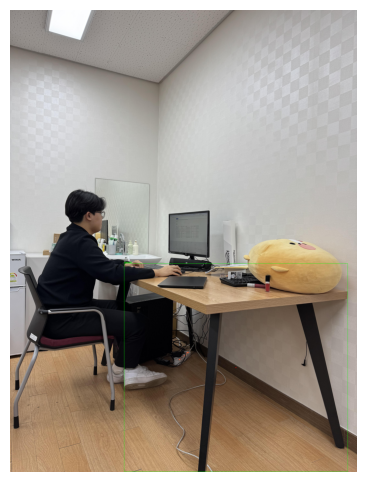

감지된 객체: ['chair', 'person', 'bottle', 'laptop', 'tv', 'bottle', 'dining table', 'cup', 'bottle', 'bottle', 'keyboard', 'refrigerator', 'keyboard', 'surfboard', 'bottle']
책상의 중앙 좌표: [(2789, 4420)]


In [ ]:
def detect_objects(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 객체 탐지 (신뢰도 낮춰서 감지)
    results = model(image, conf=0.1)

    detected_objects = []
    desk_centers = []

    for result in results:
        for box in result.boxes:
            cls_id = int(box.cls[0])
            label = model.names[cls_id]
            detected_objects.append(label)

            if label in ["table", "dining table"]:  # 책상 관련 클래스
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                center_x = (x1 + x2) // 2
                center_y = (y1 + y2) // 2
                desk_centers.append((center_x, center_y))

                # 감지된 객체 시각화
                cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.circle(image, (center_x, center_y), 5, (255, 0, 0), -1)
                cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 결과 이미지 출력
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    return detected_objects, desk_centers

In [ ]:
# 실행
image_path = "/content/drive/MyDrive/IMG_3224.jpg"
detected_objects, desk_positions = detect_objects(image_path)

# 결과 확인
print("감지된 객체:", detected_objects)
if desk_positions:
    print("책상의 중앙 좌표:", desk_positions)
else:
    print("책상이 감지되지 않았습니다.")

In [ ]:
#---- 마스킹

In [ ]:
model = YOLO("yolov8x-seg.pt")

100%|██████████| 137M/137M [00:00<00:00, 228MB/s]


In [ ]:
def detect_and_segment_table(image_path):
    # 이미지 로드
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 객체 탐지 (세그멘테이션 포함)
    results = model(image, conf=0.2)

    detected_objects = []  # 감지된 객체 목록
    mask = np.zeros_like(image, dtype=np.uint8)  # 마스크 초기화

    for result in results:
        for box, seg, cls_id in zip(result.boxes.xyxy, result.masks.xy, result.boxes.cls):
            cls_id = int(cls_id)  # 클래스 ID
            label = model.names[cls_id]  # 클래스 이름
            detected_objects.append(label)

            # 세그멘테이션 마스크 적용 (책상일 경우)
            if label in ["table", "dining table"]:
                pts = np.array(seg, dtype=np.int32)  # 세그멘테이션 좌표 변환
                cv2.fillPoly(mask, [pts], (0, 0, 255))  # 빨간색 마스킹 (책상)

            # 객체 바운딩 박스 및 레이블 표시
            x1, y1, x2, y2 = map(int, box)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 원본 이미지와 마스크 합성 (알파 블렌딩)
    alpha = 0.5
    masked_image = cv2.addWeighted(mask, alpha, image, 1 - alpha, 0)

    # 결과 이미지 출력
    plt.figure(figsize=(15, 11))
    plt.imshow(masked_image)
    plt.axis("off")
    plt.show()

    return detected_objects


0: 640x640 1 cup, 7 chairs, 2 potted plants, 6 dining tables, 7090.3ms
Speed: 8.0ms preprocess, 7090.3ms inference, 95.1ms postprocess per image at shape (1, 3, 640, 640)


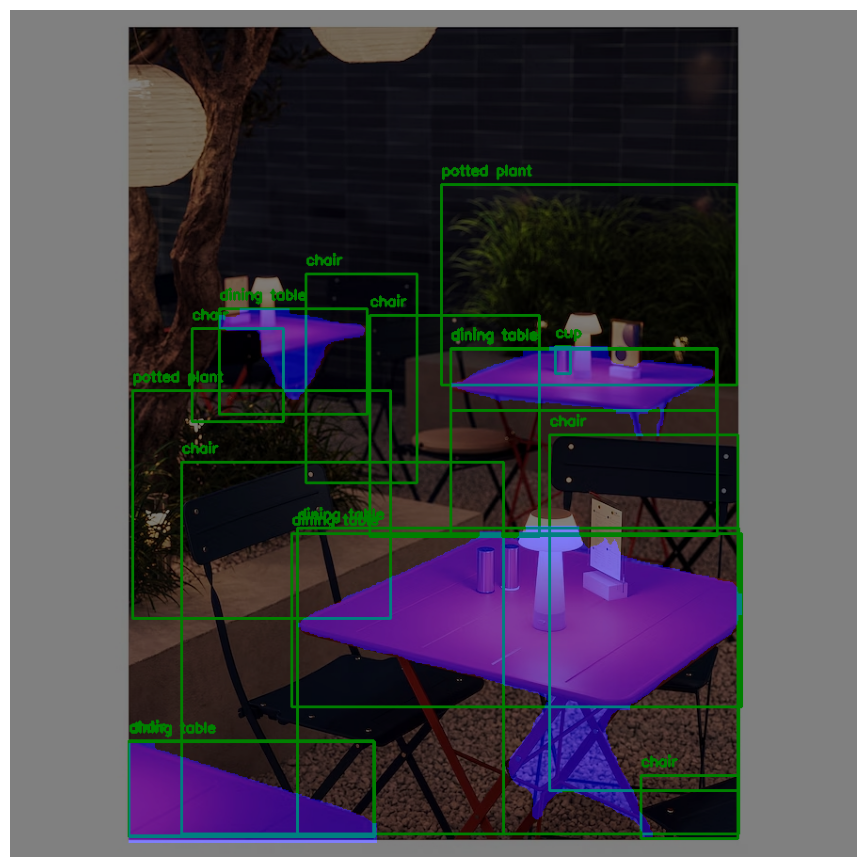

감지된 객체 목록: ['chair', 'dining table', 'chair', 'chair', 'chair', 'potted plant', 'potted plant', 'dining table', 'chair', 'chair', 'dining table', 'dining table', 'dining table', 'dining table', 'chair', 'cup']


In [ ]:
image_path = "/content/drive/MyDrive/sundsoe-table-bright-orange-outdoor__1432146_ph201914_s5.jpg"

detected_objects = detect_and_segment_table(image_path)

# 결과 출력
print("감지된 객체 목록:", detected_objects)

In [ ]:
# ================= 가장큰 객체만


0: 640x640 1 cup, 7 chairs, 2 potted plants, 6 dining tables, 5756.4ms
Speed: 5.9ms preprocess, 5756.4ms inference, 77.2ms postprocess per image at shape (1, 3, 640, 640)


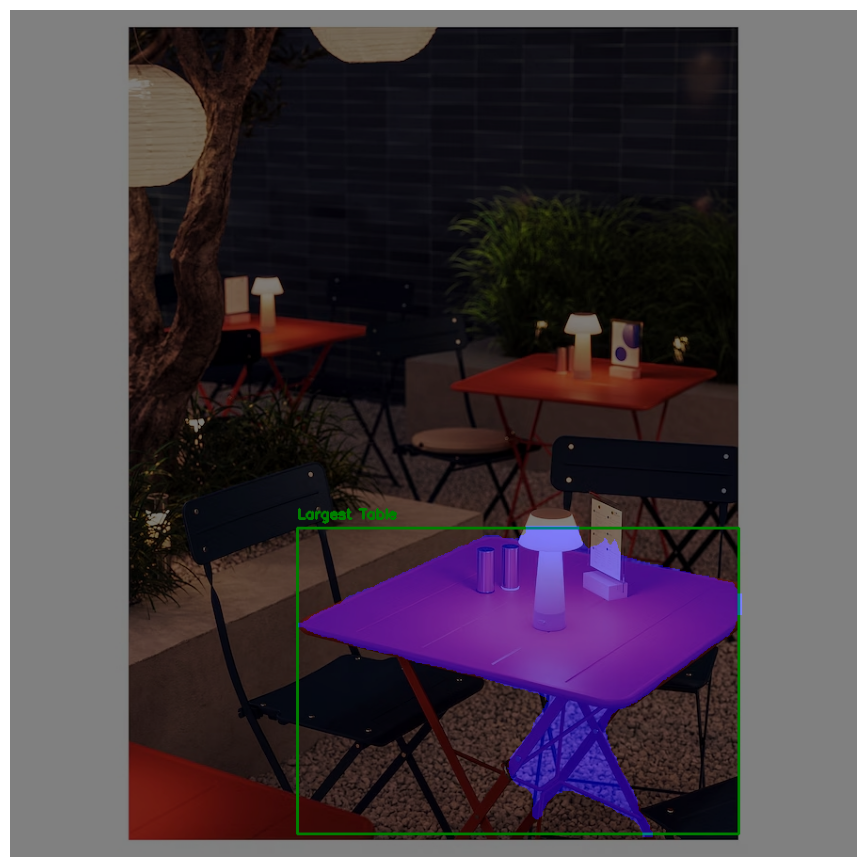

감지된 객체 목록: ['chair', 'dining table', 'chair', 'chair', 'chair', 'potted plant', 'potted plant', 'dining table', 'chair', 'chair', 'dining table', 'dining table', 'dining table', 'dining table', 'chair', 'cup']


In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# YOLOv8 Segmentation 모델 로드
model = YOLO("yolov8x-seg.pt")

def detect_largest_table(image_path):
    # 이미지 로드
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 객체 탐지 (세그멘테이션 포함)
    results = model(image, conf=0.2)

    detected_objects = []  # 감지된 객체 목록
    table_candidates = []  # 감지된 책상들 저장 (크기 비교용)

    # 초기 빈 마스크 생성
    mask = np.zeros_like(image, dtype=np.uint8)

    for result in results:
        for box, seg, cls_id in zip(result.boxes.xyxy, result.masks.xy, result.boxes.cls):
            cls_id = int(cls_id)  # 클래스 ID
            label = model.names[cls_id]  # 클래스 이름
            detected_objects.append(label)

            x1, y1, x2, y2 = map(int, box)
            area = (x2 - x1) * (y2 - y1)  # 바운딩 박스의 면적

            if label in ["table", "dining table"]:
                table_candidates.append((area, x1, y1, x2, y2, seg))  # 면적과 함께 저장

    # 가장 큰 책상 선택
    if table_candidates:
        largest_table = max(table_candidates, key=lambda x: x[0])  # 면적이 가장 큰 객체 선택
        _, x1, y1, x2, y2, seg = largest_table

        # 세그멘테이션 마스크 적용
        pts = np.array(seg, dtype=np.int32)
        cv2.fillPoly(mask, [pts], (0, 0, 255))  # 빨간색 마스킹

        # 바운딩 박스 및 라벨링 유지
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, "Largest Table", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # 원본 이미지와 마스크 합성 (알파 블렌딩)
    alpha = 0.5
    masked_image = cv2.addWeighted(mask, alpha, image, 1 - alpha, 0)

    # 결과 이미지 출력
    plt.figure(figsize=(15, 11))
    plt.imshow(masked_image)
    plt.axis("off")
    plt.show()

    return detected_objects

# 이미지 경로
image_path = "/content/drive/MyDrive/sundsoe-table-bright-orange-outdoor__1432146_ph201914_s5.jpg"

# 가장 큰 책상 탐지 및 마스킹 실행
detected_objects = detect_largest_table(image_path)

# 결과 출력
print("감지된 객체 목록:", detected_objects)


In [ ]:
def detect_largest_table_and_center(image_path):
    # 이미지 로드
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 객체 탐지 (세그멘테이션 포함)
    results = model(image, conf=0.2)

    detected_objects = []  # 감지된 객체 목록
    table_candidates = []  # 감지된 책상들 저장 (크기 비교용)

    # 초기 빈 마스크 생성
    mask = np.zeros_like(image, dtype=np.uint8)

    for result in results:
        for box, seg, cls_id in zip(result.boxes.xyxy, result.masks.xy, result.boxes.cls):
            cls_id = int(cls_id)  # 클래스 ID
            label = model.names[cls_id]  # 클래스 이름
            detected_objects.append(label)

            x1, y1, x2, y2 = map(int, box)
            area = (x2 - x1) * (y2 - y1)  # 바운딩 박스의 면적

            if label in ["table", "dining table"]:
                table_candidates.append((area, x1, y1, x2, y2, seg))  # 면적과 함께 저장

    # 가장 큰 책상 선택
    if table_candidates:
        largest_table = max(table_candidates, key=lambda x: x[0])  # 면적이 가장 큰 객체 선택
        _, x1, y1, x2, y2, seg = largest_table

        # 세그멘테이션 마스크 적용
        pts = np.array(seg, dtype=np.int32)
        cv2.fillPoly(mask, [pts], (0, 0, 255))  # 빨간색 마스킹

        # 바운딩 박스 및 라벨링 유지
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, "Largest Table", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 상판의 가운데 좌표 계산
        center_x = (x1 + x2) // 2
        center_y = (y1 + y2) // 2

        # 가운데 좌표 표시
        cv2.circle(image, (center_x, center_y), 5, (0, 0, 255), -1)
        cv2.putText(image, f"Center: ({center_x}, {center_y})", (center_x + 10, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # 원본 이미지와 마스크 합성 (알파 블렌딩)
    alpha = 0.5
    masked_image = cv2.addWeighted(mask, alpha, image, 1 - alpha, 0)

    # 결과 이미지 출력
    plt.figure(figsize=(15, 11))
    plt.imshow(masked_image)
    plt.axis("off")
    plt.show()

    return detected_objects, (center_x, center_y)


0: 640x640 1 cup, 7 chairs, 2 potted plants, 6 dining tables, 5786.5ms
Speed: 6.6ms preprocess, 5786.5ms inference, 110.6ms postprocess per image at shape (1, 3, 640, 640)


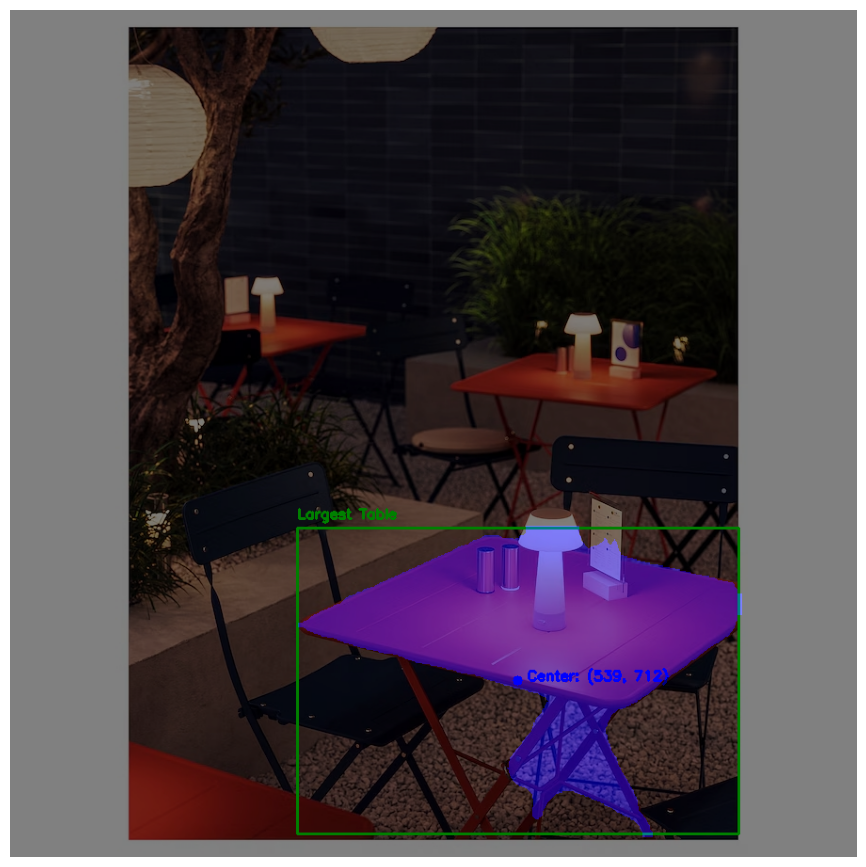

감지된 객체 목록: ['chair', 'dining table', 'chair', 'chair', 'chair', 'potted plant', 'potted plant', 'dining table', 'chair', 'chair', 'dining table', 'dining table', 'dining table', 'dining table', 'chair', 'cup']
가장 큰 책상의 상판 가운데 좌표: (539, 712)


In [ ]:
# 이미지 경로
image_path = "/content/drive/MyDrive/sundsoe-table-bright-orange-outdoor__1432146_ph201914_s5.jpg"

detected_objects, center = detect_largest_table_and_center(image_path)

# 결과 출력
print("감지된 객체 목록:", detected_objects)
print("가장 큰 책상의 상판 가운데 좌표:", center)

In [ ]:
# =========== 다각형 넓이를 이용한 중심점 찾기

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# YOLOv8 Segmentation 모델 로드
model = YOLO("yolov8x-seg.pt")

def detect_largest_table_and_center(image_path):
    # 이미지 로드
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 객체 탐지 (세그멘테이션 포함)
    results = model(image_rgb, conf=0.2)

    detected_objects = []  # 감지된 객체 목록
    table_candidates = []  # 감지된 책상들 저장 (크기 비교용)

    # 초기 빈 마스크 생성
    mask = np.zeros_like(image_rgb, dtype=np.uint8)

    for result in results:
        for box, seg, cls_id in zip(result.boxes.xyxy, result.masks.xy, result.boxes.cls):
            cls_id = int(cls_id)  # 클래스 ID
            label = model.names[cls_id]  # 클래스 이름
            detected_objects.append(label)

            x1, y1, x2, y2 = map(int, box)
            area = (x2 - x1) * (y2 - y1)  # 바운딩 박스의 면적

            if label in ["table", "dining table"]:
                table_candidates.append((area, x1, y1, x2, y2, seg))  # 면적과 함께 저장

    # 가장 큰 책상 선택
    if table_candidates:
        largest_table = max(table_candidates, key=lambda x: x[0])  # 면적이 가장 큰 객체 선택
        _, x1, y1, x2, y2, seg = largest_table

        # 세그멘테이션 마스크 적용
        pts = np.array(seg, dtype=np.int32)
        cv2.fillPoly(mask, [pts], (0, 0, 255))  # 빨간색 마스킹

        # 바운딩 박스 및 라벨링 유지
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image_rgb, "Largest Table", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 상판의 가운데 좌표 계산: 다각형의 중심
        M = cv2.moments(pts)  # 다각형의 모멘트를 사용하여 중심 계산
        if M["m00"] != 0:
            center_x = int(M["m10"] / M["m00"])
            center_y = int(M["m01"] / M["m00"])
        else:
            center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2  # 예외 처리: 중심을 바운딩 박스의 중앙으로 설정

        # 가운데 좌표 표시
        cv2.circle(image_rgb, (center_x, center_y), 5, (0, 0, 255), -1)
        cv2.putText(image_rgb, f"Center: ({center_x}, {center_y})", (center_x + 10, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # 원본 이미지와 마스크 합성 (알파 블렌딩)
    alpha = 0.5
    masked_image = cv2.addWeighted(mask, alpha, image_rgb, 1 - alpha, 0)

    # 결과 이미지 출력
    plt.figure(figsize=(15, 11))
    plt.imshow(masked_image)
    plt.axis("off")
    plt.show()

    return detected_objects, (center_x, center_y)


0: 640x640 1 cup, 7 chairs, 2 potted plants, 6 dining tables, 6046.8ms
Speed: 4.7ms preprocess, 6046.8ms inference, 66.3ms postprocess per image at shape (1, 3, 640, 640)


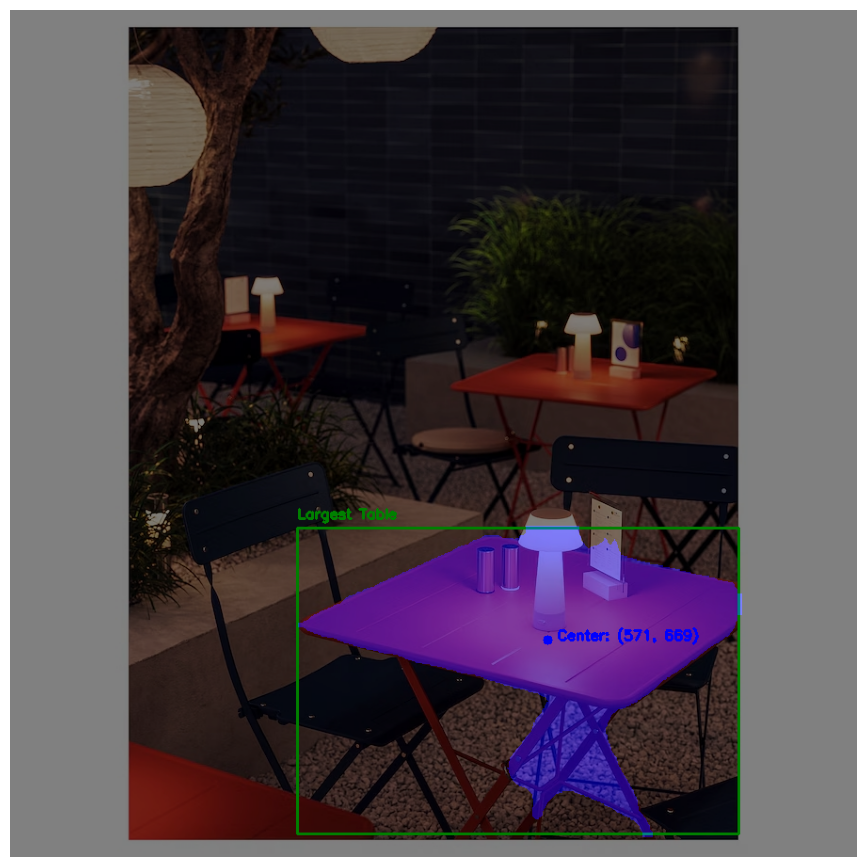

감지된 객체 목록: ['chair', 'dining table', 'chair', 'chair', 'chair', 'potted plant', 'potted plant', 'dining table', 'chair', 'chair', 'dining table', 'dining table', 'dining table', 'dining table', 'chair', 'cup']
가장 큰 책상의 상판 가운데 좌표: (571, 669)


In [ ]:
# 이미지 경로
image_path = "/content/drive/MyDrive/sundsoe-table-bright-orange-outdoor__1432146_ph201914_s5.jpg"

# 가장 큰 책상 탐지 및 상판의 가운데 좌표 출력
detected_objects, center = detect_largest_table_and_center(image_path)

# 결과 출력
print("감지된 객체 목록:", detected_objects)
print("가장 큰 책상의 상판 가운데 좌표:", center)

In [ ]:
#---------------- 다른 이미지

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# YOLOv8 Segmentation 모델 로드
model = YOLO("yolov8x-seg.pt")

def detect_largest_table_and_center1(image_path):
    # 이미지 로드
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 객체 탐지 (세그멘테이션 포함)
    results = model(image_rgb, conf=0.2)

    detected_objects = []  # 감지된 객체 목록
    table_candidates = []  # 감지된 책상들 저장 (크기 비교용)

    # 초기 빈 마스크 생성
    mask = np.zeros_like(image_rgb, dtype=np.uint8)

    for result in results:
        for box, seg, cls_id in zip(result.boxes.xyxy, result.masks.xy, result.boxes.cls):
            cls_id = int(cls_id)  # 클래스 ID
            label = model.names[cls_id]  # 클래스 이름
            detected_objects.append(label)

            x1, y1, x2, y2 = map(int, box)
            area = (x2 - x1) * (y2 - y1)  # 바운딩 박스의 면적

            if label in ["table", "dining table", "chair", "Largest Table"]:
                table_candidates.append((area, x1, y1, x2, y2, seg))  # 면적과 함께 저장

    # 가장 큰 책상 선택
    if table_candidates:
        largest_table = max(table_candidates, key=lambda x: x[0])  # 면적이 가장 큰 객체 선택
        _, x1, y1, x2, y2, seg = largest_table

        # 세그멘테이션 마스크 적용
        pts = np.array(seg, dtype=np.int32)
        cv2.fillPoly(mask, [pts], (0, 0, 255))  # 빨간색 마스킹

        # 바운딩 박스 및 라벨링 유지
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image_rgb, "Largest Table", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 상판의 가운데 좌표 계산: 다각형의 중심
        M = cv2.moments(pts)  # 다각형의 모멘트를 사용하여 중심 계산
        if M["m00"] != 0:
            center_x = int(M["m10"] / M["m00"])
            center_y = int(M["m01"] / M["m00"])
        else:
            center_x, center_y = (x1 + x2) // 2, (y1 + y2) // 2  # 예외 처리: 중심을 바운딩 박스의 중앙으로 설정

        # 가운데 좌표 표시
        cv2.circle(image_rgb, (center_x, center_y), 5, (0, 0, 255), -1)
        cv2.putText(image_rgb, f"Center: ({center_x}, {center_y})", (center_x + 10, center_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

    # 원본 이미지와 마스크 합성 (알파 블렌딩)
    alpha = 0.5
    masked_image = cv2.addWeighted(mask, alpha, image_rgb, 1 - alpha, 0)

    # 결과 이미지 출력
    plt.figure(figsize=(15, 11))
    plt.imshow(masked_image)
    plt.axis("off")
    plt.show()

    return detected_objects, (center_x, center_y)


0: 640x480 1 bottle, 1 cup, 1 chair, 1 potted plant, 1 vase, 4315.4ms
Speed: 5.2ms preprocess, 4315.4ms inference, 18.8ms postprocess per image at shape (1, 3, 640, 480)


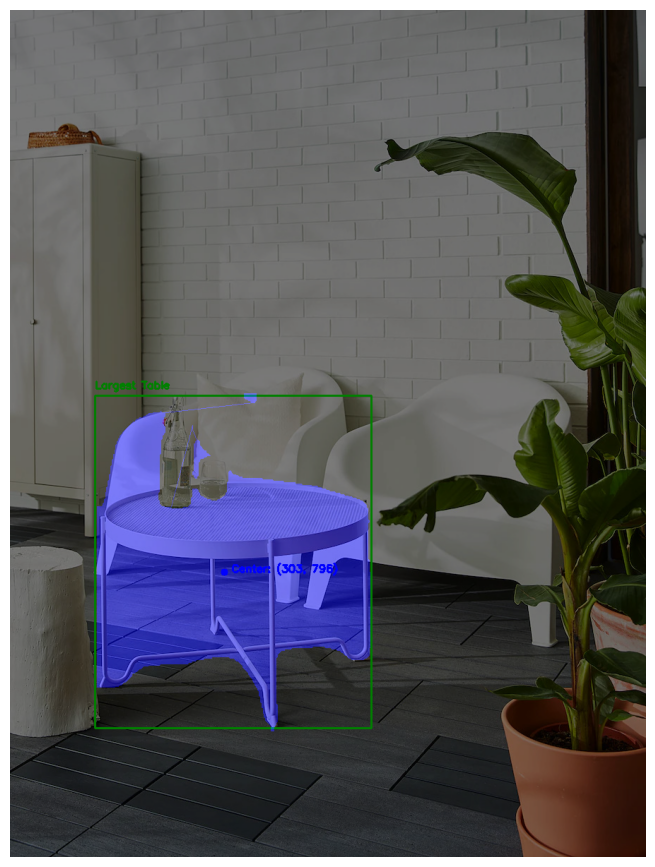

감지된 객체 목록: ['bottle', 'potted plant', 'cup', 'chair', 'vase']
가장 큰 책상의 상판 가운데 좌표: (303, 796)


In [ ]:
# 이미지 경로
image_path = "/content/drive/MyDrive/krokholmen-coffee-table-outdoor-beige__0979042_ph175831_s5.jpg"

# 가장 큰 책상 탐지 및 상판의 가운데 좌표 출력
detected_objects, center = detect_largest_table_and_center1(image_path)

# 결과 출력
print("감지된 객체 목록:", detected_objects)
print("가장 큰 책상의 상판 가운데 좌표:", center)


0: 640x640 2 chairs, 2 dining tables, 6364.0ms
Speed: 6.4ms preprocess, 6364.0ms inference, 18.7ms postprocess per image at shape (1, 3, 640, 640)


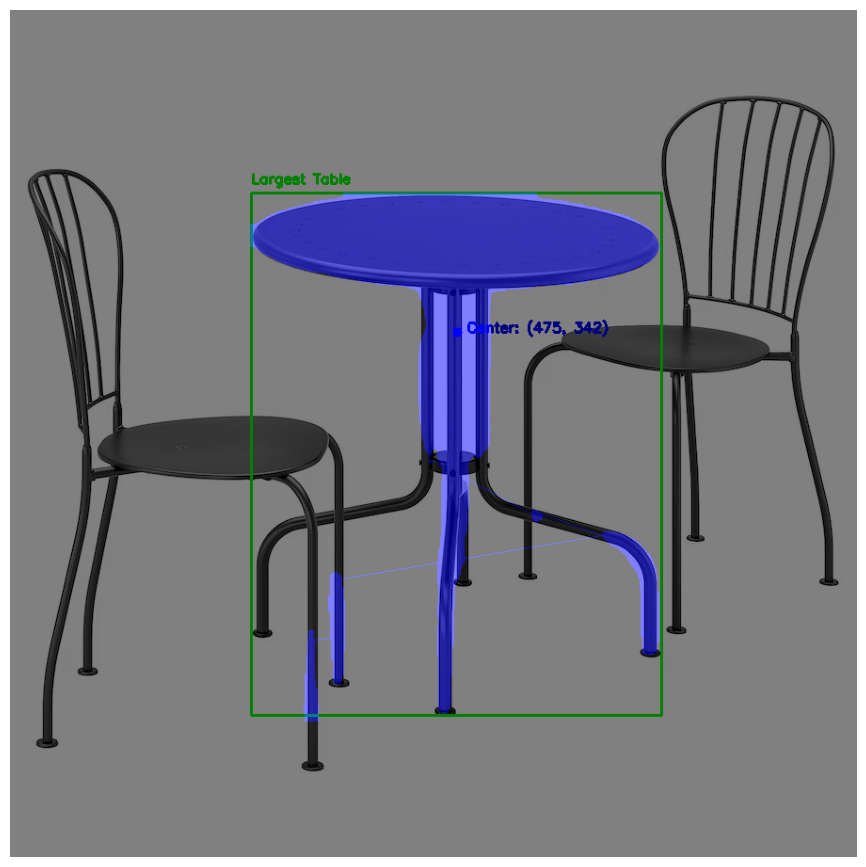

감지된 객체 목록: ['chair', 'chair', 'dining table', 'dining table']
가장 큰 책상의 상판 가운데 좌표: (475, 342)


In [ ]:
# 이미지 경로
image_path = "/content/drive/MyDrive/laeckoe-table-2-chairs-outdoor-grey__0735585_pe740066_s5.jpg"

# 가장 큰 책상 탐지 및 상판의 가운데 좌표 출력
detected_objects, center = detect_largest_table_and_center(image_path)

# 결과 출력
print("감지된 객체 목록:", detected_objects)
print("가장 큰 책상의 상판 가운데 좌표:", center)